# Exercise Sheet 03: Semantic Network and RDF

**Knowledge Representation Summer 2026**  
**Bielefeld University**  
**Adia Khalid, Benjamin Paaßen**  
**Exercise Sheet Publication Date: 2026-05-26**  
**Exercise Sheet Submission Deadline: Friday, 2026-06-05, noon (i.e. 23:59), via moodle**

**NOTE** The use of language models/AI tools is permitted under three conditions
1. transparency: you tell us that you used them
2. accountability: you take full responsibility for the submission, can explain and defend it
3. privacy: you do not transmit any private information to any external tool

## Semantic Network

## Example data set
The file `dataset_sheet3.csv` contains fictional data as might be produced in a psychological study. Each row represents a participant in the study. The first column is just the participant index, the second column indicates the group the participant was in (1 for *Low Openness*, 2 for *High Openness*). The third column is the participant's openness score. The remaining 15 columns (R1–R15) contain the animal names listed by each participant, padded with `NaN` where fewer than 15 animals were named.

The following line loads this raw data and prints it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

X = np.genfromtxt("dataset_sheet3.csv", delimiter=",", dtype=str)
print(X)

[['participant' 'group' 'score' ... 'R13' 'R14' 'R15']
 ['1' '1' '55.0' ... 'nan' 'nan' 'nan']
 ['2' '1' '48.6' ... 'nan' 'nan' 'nan']
 ...
 ['514' '2' '60.9' ... 'nan' 'nan' 'nan']
 ['515' '2' '64.2' ... 'nan' 'nan' 'nan']
 ['516' '2' '77.6' ... 'snake' 'cow' 'nan']]


### Task 03.01
Perform a small descriptive analysis of the data.

1. Print the number of participants in each group.
2. What is the range (minimum and maximum) of openness scores?
3. Print the number of response columns.

In [2]:
# Skip the header row to work with the actual data
data = X[1:]

# TODO 1: Print the number of participants in each group (group 1 and group 2).
#         Hint: data[:, 1] holds the group column as strings.

group_column = data[:, 1]
print("Participants in group 1:")
print(group_column.tolist().count('1'))

print("Participants in group 2:")
print(group_column.tolist().count('2'))


# TODO 2: Print the minimum and maximum of the openness scores.
#         Hint: data[:, 2] holds the score column as strings — convert to float.
highest = 0
lowest = float(data[:, 2][0])
for x in data[:, 2]: 
    y = float(x)
    if y > highest:
        highest = y
    elif  y < lowest:
        lowest = y
print("Maximum openness score:")
print(highest)
print("Minimum openness score")
print(lowest)

# TODO 3: Print the number of response columns (R1–R15).
#         Hint: look at X.shape and the column headers in X[0].
# https://numpy.org/doc/stable/reference/generated/numpy.shape.html
# https://www.geeksforgeeks.org/python/how-to-check-if-a-string-can-be-converted-to-float-in-python/

count = 0
for a in X[0]:
    if 'R' in a:
        count = count+1

print("Number of response colums:")
print(count)

#print("Number of rows:")
#print(X.shape)



Participants in group 1:
258
Participants in group 2:
258
Maximum openness score:
100.8
Minimum openness score
23.8
Number of response colums:
15


### Co-occurrence matrix

Two responses **co-occur** if they appear within some window (distance) of each other in the same participant's response list.

Let $C$ be the co-occurrence matrix where

$$C_{ij} = \text{number of times animals } i \text{ and } j \text{ co-occur within window size } w$$

For example, with window size $w = 2$ and responses `[cat, dog, mouse, wolf]`:
- `cat` co-occurs with `dog` (distance 1) and `mouse` (distance 2)
- `dog` co-occurs with `cat`, `mouse`, and `wolf`
- etc.

The matrix is symmetric ($C_{ij} = C_{ji}$) and the diagonal is typically left as 0.

### Task 03.02
Build a co-occurrence matrix from the verbal fluency responses.

In [10]:
import pandas as pd
import numpy as np
from collections import defaultdict

def create_cooccurrence_matrix(X, response_cols, window_size=2):
    """
    Create a co-occurrence matrix from verbal fluency responses.

    Parameters
    ----------
    X : np.ndarray
        Full data array (including header row).
    response_cols : list of int
        Column indices in X that contain animal responses.
    window_size : int
        Maximum distance between two animals to count them as co-occurring.

    Returns
    -------
    cooccurrence_df : pd.DataFrame
        Symmetric DataFrame indexed by animal names with co-occurrence counts.
    """

    data = []
    
    # TODO 1: Collect the responses of each participant (skip the header row,
    #         skip "nan" entries, and lower-case the animal names).
    # https://www.geeksforgeeks.org/python/different-ways-to-create-pandas-dataframe/
    #https://stackoverflow.com/questions/72015664/how-do-i-easily-remove-a-string-element-from-a-numpy-array-of-strings
    # https://stackoverflow.com/questions/1801668/convert-a-list-with-strings-all-to-lowercase-or-uppercase
    # https://www.geeksforgeeks.org/python/python-merge-two-lists-without-duplicates/
    
    response_cols_headless = response_cols[1:]
    all_animals = []
    
   
    for row in response_cols_headless:
        row_clean = row[row != 'nan'].tolist()
        row_lowercase = [x.lower() for x in row_clean]
        data.append(row_lowercase)
        all_animals = list(set(all_animals + row_lowercase)) 

    all_animals.sort()
    

    # TODO 2: Build a defaultdict(int) that counts co-occurrences of pairs
    #         (animal_i, animal_j) within the given window_size. Increment
    #         both (i, j) and (j, i) so the matrix becomes symmetric.

    dictionary = defaultdict(int)

    for row in data: 
        leng = len(row)
        for index in range(leng):
            # Increment for next animal 
            x = row[index]
            if index < leng-1: 
                y = row[index+1]
                dictionary[(x,y)] += 1
                dictionary[(y,x)] += 1
                if index < leng-2:
                    y = row[index+2]
                    dictionary[(x,y)] += 1
                    dictionary[(y,x)] += 1
            

    # TODO 3: Collect the set of all unique animals, build a DataFrame of
    #         zeros with shape (n_animals, n_animals), and fill it from the
    #         dict you built in step 2.
    # https://stackoverflow.com/questions/13842088/set-value-for-particular-cell-in-pandas-dataframe-using-index
    # https://www.geeksforgeeks.org/python/how-to-create-an-array-of-zeros-in-python/

    ### -> Set of all unique animals is build in Step 1.
    
    zeroes = [0] * len(all_animals)
    cooccurrence = {}
    for animal in all_animals: 
        cooccurrence.update({
            animal: pd.Series(zeroes, all_animals)
        })

    cooccurrence_df = pd.DataFrame(cooccurrence)

    for key, value in dictionary.items():
        x = key[0]
        y = key[1]
        cooccurrence_df.at[x, y] = value
    
    #print(cooccurrence_df)
    
    return cooccurrence_df


# TODO 4: Call create_cooccurrence_matrix with the response columns from X
#         and display the 5 most frequently co-occurring animal pairs.
# https://stackoverflow.com/questions/34417685/melt-the-upper-triangular-matrix-of-a-pandas-dataframe

cooccurrence_df = create_cooccurrence_matrix(X, X[: , 3:])

upper_half_df = cooccurrence_df.where(np.triu(np.ones(cooccurrence_df.shape)).astype(np.bool))

maxes = upper_half_df.max().sort_values(ascending=False).iloc[0:5].to_dict()

max_per_animal = upper_half_df.idxmax().to_dict()

for key, value in maxes.items():
    print(f"{key}: {max_per_animal[key]} with {value}")


lion: elephant with 93.0
zebra: bear with 89.0
snake: cow with 86.0
horse: cat with 85.0
mouse: giraffe with 85.0


### Task 03.03
Visualize the semantic network using NetworkX.

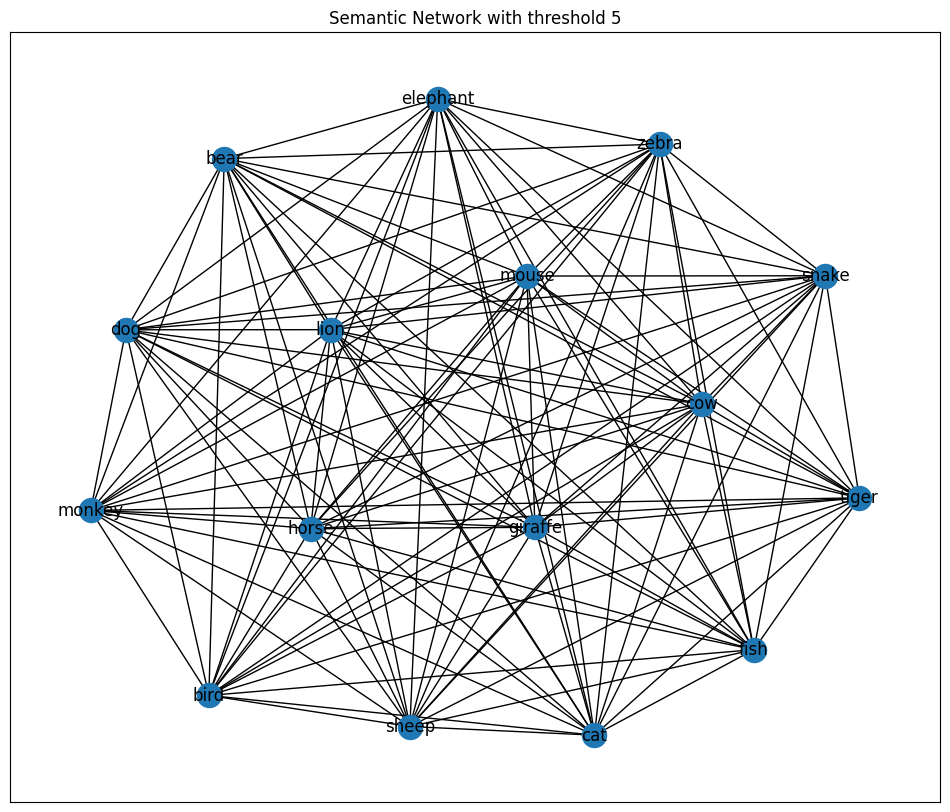

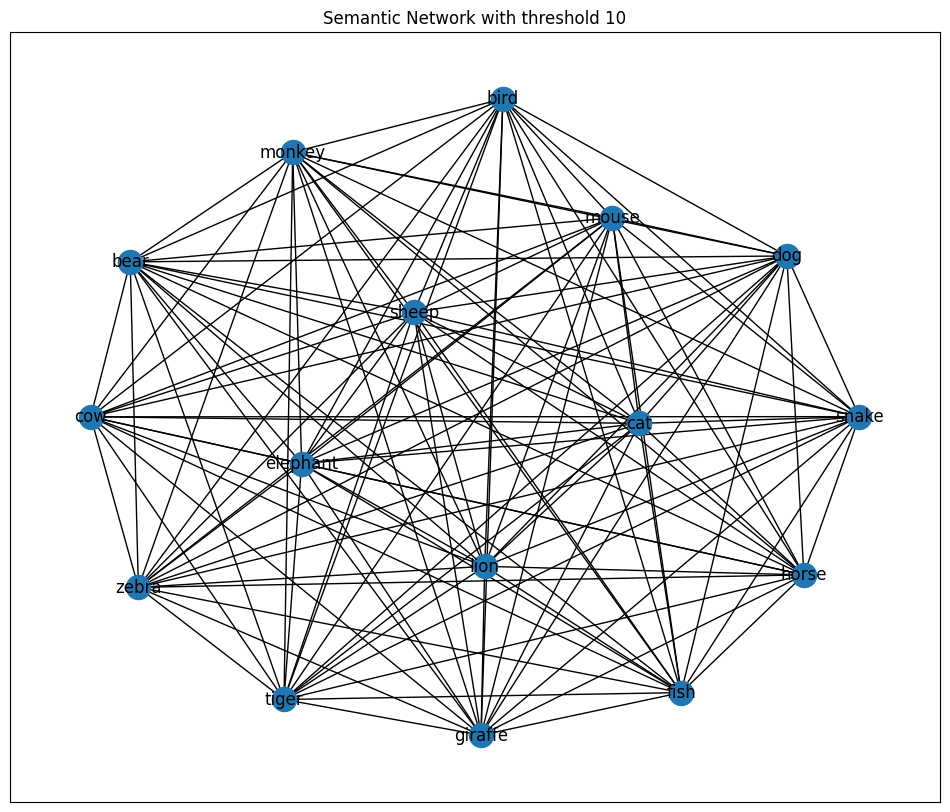

In [97]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_semantic_network(cooccurrence_df, threshold=5, title="Semantic Network"):
    """
    Draw a semantic network from a co-occurrence matrix.

    Parameters
    ----------
    cooccurrence_df : pd.DataFrame
        Symmetric co-occurrence DataFrame indexed by animal names.
    threshold : int
        Minimum co-occurrence count required to draw an edge.
    title : str
        Plot title.

    Returns
    -------
    G : networkx.Graph
        The constructed graph.
    """
    G = nx.Graph()
    animals = cooccurrence_df.index.tolist()
    G.add_nodes_from(animals)

    # TODO 1: Iterate over all pairs (i, j) with i < j in the co-occurrence
    #         matrix and add an edge with weight = co-occurrence count
    #         whenever the count is strictly greater than `threshold`.

    for i in range(len(animals)):
        for j in range(len(animals)):
            if i >= j: 
                continue
            if cooccurrence_df[animals[i]][animals[j]] > threshold:
                G.add_edge(animals[i], animals[j],  weight=cooccurrence_df[animals[i]][animals[j]])
                #print("Added " + animals[i] + " to " + animals[j])

    # TODO 2: Draw the graph with matplotlib.
    #         - Use nx.spring_layout for positions.
    #         - Use nx.draw_networkx_nodes / _edges / _labels.
    #         - Edge widths should reflect the edge weight.
    #         - Set the title and call plt.show().

    
    plt.figure(figsize=(12, 10))
    plt.title(f"{title} with threshold {str(threshold)}")

    pos = nx.spring_layout(G, method="energy", weight="weight", gravity=0.00000001)
    
    nodes = nx.draw_networkx_nodes(G, pos=pos)
    edges = nx.draw_networkx_edges(G, pos=pos)
    labels = nx.draw_networkx_labels(G, pos=pos)
    plt.show()

    return G

#print(cooccurrence_df)
# TODO 3: Call draw_semantic_network with threshold=5 and again with threshold=10.
#         Compare the two networks visually.

#### -> The length of the edges is not proportional to the edge weights, just influcend by them. The differences are only really 
#### visible with a threshold of 60 or higher, as the many edges do not allow for a more accurate spacing otherwise. 
#### The graph with thresholf 5 shows very little grouping. The one with threshold 10 neither, but it is visible that some animals 
#### are situated differently. 
#### It is notable that with a threshold of 10, most mammal carnivores are close together and the elephant took a central spot. 

result_thresh_five = draw_semantic_network(cooccurrence_df)
draw_semantic_network(cooccurrence_df, 10)

#draw_semantic_network(cooccurrence_df, 60)


### Task 03.04
Calculate the **clustering coefficient**, **average shortest path length**, and **modularity** of the semantic network.

**Modularity** (see [Wikipedia: Modularity (networks)](https://en.wikipedia.org/wiki/Modularity_(networks))) measures how well a network can be split into communities. Implement the standard definition

$$Q = \frac{1}{2m} \sum_{v,w} \left[ A_{vw} - \frac{k_v k_w}{2m} \right] \delta(c_v, c_w)$$

where
- $m$ is the total number of edges in the graph,
- $A_{vw}$ is 1 if there is an edge between nodes $v$ and $w$ (0 otherwise),
- $k_v$ is the degree of node $v$,
- $c_v$ is the community (group) node $v$ belongs to,
- $\delta(c_v, c_w) = 1$ if $v$ and $w$ are in the same community, 0 otherwise.

A high $Q$ (typically $> 0.3$) means the network has clear community structure.

In [124]:
from networkx.algorithms.community import greedy_modularity_communities

def compute_network_measures(G, network_name="Network"):
    """
    Compute three semantic-network measures:
    1. Average Shortest Path Length (ASPL)
    2. Average Clustering Coefficient (CC)
    3. Modularity (Q) using the formula above
    """
    measures = {}

    # --- Average Shortest Path Length -------------------------------------
    if nx.is_connected(G):
        # TODO 1a: Compute the average shortest path length of G.
        measures['ASPL'] = nx.average_shortest_path_length(G)
    else:
        # TODO 1b: For disconnected graphs, compute ASPL on the LARGEST
        #          connected component.
        measures['ASPL'] = max(nx.connected_components(G), key=len)

    # --- Clustering Coefficient ------------------------------------------
    # TODO 2: Compute the average clustering coefficient of G.
    measures['CC'] = nx.average_clustering(G)

    # --- Modularity -------------------------------------------------------
    communities = list(greedy_modularity_communities(G))
    m = G.number_of_edges()

    # TODO 3: Build a dict node -> community index for fast lookup.

    node_community_dict = {}
    
    for index, community in enumerate(communities):
        for node in community:
            node_community_dict[node] = index
        

    # TODO 4: Implement the modularity formula above.
    #         Iterate over all pairs (v, w) of nodes. For each pair:
    #           - A_vw = 1 if (v, w) is an edge of G, else 0
    #           - subtract k_v * k_w / (2m)
    #           - multiply by 1 if both nodes are in the same community, else 0
    #         Sum everything and divide by 2m.

    sum_v_w = 0

    for v in G.nodes:
        for w in G.nodes:
            if v == w:
                continue
            # A_vw
            if G.has_edge(v,w):
                A_vw = 1
            else: 
                A_vw = 0
           
            #  k_v * k_w / (2m)
            fraction = ( (G.degree(v) * G.degree(w))) / (2 * m)
           
            # [A_vw - (k_v * k_w / (2m))]
            square_brackets = A_vw - fraction
           
            # multiply by 1 if both nodes are in the same community, else 0
            if node_community_dict[v] == node_community_dict[w]:
                same_community = 1
            else:
                same_community = 0

            all_together = square_brackets * same_community
          
            sum_v_w += all_together
          
    Q = sum_v_w

    measures['Q'] = Q
    return measures


# TODO 5: Use the network with threshold=5 from Task 03.03 to compute and
#         print all three measures.
compute_network_measures(result_thresh_five)

{'bear': 0, 'mouse': 0, 'bird': 0, 'sheep': 0, 'cow': 0, 'zebra': 0, 'fish': 0, 'giraffe': 0, 'dog': 0, 'snake': 0, 'tiger': 0, 'elephant': 0, 'lion': 0, 'monkey': 0, 'horse': 0, 'cat': 0}


{'ASPL': 1.0, 'CC': 1.0, 'Q': 15.0}

**Answer here:** What is meant by *low ASPL*, *high CC* and *high modularity*? Explain briefly what each tells you about the semantic network.

## RDF

In [6]:
!pip install rdflib

Defaulting to user installation because normal site-packages is not writeable


In [7]:
from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import FOAF, RDF
import rdflib

print("rdflib version:", rdflib.__version__)

# Create a simple graph with one triple
g = Graph()
bob = URIRef("http://example.org/people/Bob")
alice = URIRef("http://example.org/people/Alice")
g.add((bob, FOAF.knows, alice))

print("Number of triples:", len(g))

rdflib version: 7.6.0
Number of triples: 1


### Task 03.05
Create RDF triples from semantic network edges.

In [8]:
"""
Task 03.05: Create RDF triples from semantic network edges.
"""
from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import RDF, XSD

def create_rdf_from_network(animal_pairs, base_uri="http://example.org/animals/"):
    """
    Convert animal co-occurrence pairs to RDF triples.

    For each pair (animal1, animal2, weight):
        <base_uri/animal1> <rel:related_to> <base_uri/animal2>
        <base_uri/animal1> <rel:weight>     "weight"^^xsd:integer

    For each unique animal:
        <base_uri/animal> rdf:type <http://example.org/Animal>
    """
    g = Graph()
    ns = Namespace(base_uri)
    rel = Namespace("http://example.org/relation/")
    animal_class = URIRef("http://example.org/Animal")

    # TODO 1: Collect the set of all unique animals appearing in animal_pairs.


    # TODO 2: For every unique animal, add the triple
    #             <ns[animal]> rdf:type <animal_class>


    # TODO 3: For every (a1, a2, weight) in animal_pairs, add
    #             <ns[a1]> rel.related_to <ns[a2]>
    #             <ns[a1]> rel.weight     Literal(weight, datatype=XSD.integer)


    return g


# Test with a small example network like:
animal_pairs = [
    ("cat",   "dog",    5),
    ("cat",   "mouse",  3),
    ("dog",   "cat",    5),
    ("dog",   "wolf",   2),
    ("mouse", "cheese", 4),
]

rdf_graph = create_rdf_from_network(animal_pairs)

print("=== RDF Graph Created ===")
print("Number of triples:", len(rdf_graph))
print("\n=== Turtle Serialization ===")
# TODO 4: Serialize and print rdf_graph in Turtle format.



=== RDF Graph Created ===
Number of triples: 0

=== Turtle Serialization ===


### Task 03.06
Write RDF triples in Turtle format **by hand** (no rdflib serializer).

In [9]:
def triple_to_turtle(subject, predicate, object_, prefixes=None):
    """
    Convert an RDF triple to Turtle format.

    Parameters
    ----------
    subject, predicate, object_ : str
        URIs as strings.
    prefixes : dict, optional
        Prefix mappings, e.g. {'rdf': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#'}.

    Returns
    -------
    str
        A multi-line Turtle representation containing the @prefix declarations
        (if any) and the triple itself, ending with " .".
    """
    turtle_lines = []

    # TODO 1: If prefixes were provided, append a line
    #             @prefix <name>: <<uri>> .
    #         for each entry.


    # TODO 2: Build a small helper that shortens a full URI using the prefix
    #         map when possible (e.g. "http://.../rdf-syntax-ns#type" becomes
    #         "rdf:type"). Otherwise wrap it in angle brackets: "<...>".


    # TODO 3: Assemble the triple line "<subj> <pred> <obj> ." using your
    #         helper and append it to turtle_lines.


    return "\n".join(turtle_lines)


# TODO 4: Define a prefix dictionary that includes at least `rdf` and `ex`
#         (for http://example.org/), and convert one example triple — for
#         instance ("http://example.org/cat", rdf:type, "http://example.org/Animal")
#         — to Turtle format. Print the result.


**Answer here:** What does the `a` shorthand mean in Turtle? Give an example using the function above.

### Task 03.07
Write a small JSON-LD document representing the same kind of statement as the rdflib example above (Bob knows Alice).

In [10]:
import json

# TODO 1: Complete the JSON-LD document below so that it represents the triple
#             <http://example.org/people/Bob> foaf:knows <http://example.org/people/Alice>
#         Hint: the "knows" key in @context should map to the full FOAF URI.
jsonld_data = {
    "@context": {
        "knows": ...   # TODO
    },
    "@id": ...,        # TODO: Bob's IRI
    "knows": {
        "@id": ...     # TODO: Alice's IRI
    }
}

# TODO 2: Pretty-print jsonld_data with json.dumps(..., indent=2).





#### TODO 3 (written answer): What does "@id" represent? 
Identify the two @id values you set above and explain what they refer to.


#### TODO 4 (written answer): What does "@context" do? 
Explain it in the context of this specific example.

#### TODO 5 (written answer): What RDF triple does this JSON-LD document represent? 
Write it out in the form (subject, predicate, object).